# Choosing k for KMeans clustering

Sweeps k over a NEMI ensemble and scores each k with four criteria from
`metrics.kmeans_eval`:

- **AIC / BIC** — from a GMM fitted to the member embedding at that k. Lower is
  better; BIC penalises k harder, so it favours fewer clusters.
- **SSE** — within-cluster sum of squares from the KMeans labels. Falls
  monotonically with k, so read the elbow rather than the minimum.
- **Silhouette** — cluster separation from the KMeans labels, in [-1, 1]. Higher
  is better, and unlike the other three it is not monotone in k, so its peak is
  directly meaningful.

The ensemble is built once (cuML UMAP, `assess_overlap=False`); every k is then
clustered with cuML KMeans on those same member embeddings, so member spread
reflects UMAP stochasticity and k values are compared pairwise across members.
Each panel plots the ensemble mean with the member min–max range shaded.

In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import metrics.kmeans_eval as kmeans_eval
from nemi import NEMI, SingleNemi

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [3]:
#data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

data_channels_small = ['Eta','Salt','Theta','U','V','gradb2','oceQnet','wind_stress_curl']
#data_channels_engineered = ['gradb2','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
dataset = cutouts_dataset.CutoutDataset.from_source(data_channels=data_channels_small, source=source, subset=False,
                                                    subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33451 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:41991' processes=4 threads=32, memory=128.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/33451/status
dropped 0 ice, 0 NaN; kept 3250 / 3250
features ['Eta', 'Salt', 'Theta', 'U', 'V', 'gradb2', 'oceQnet', 'wind_stress_curl'] | coords ['XC', 'YC']


In [4]:
patch_size = 8
patches = dataset.get_patches(patch_size=patch_size)   # (N_patches, C_feat*p*p), coords excluded

print(patches.shape)

(208000, 512)


In [5]:
EMBEDDING_DIMENSIONS = 3
ENSEMBLE_MEMBERS = 2
K_VALUES = [8, 10, 50, 100, 500, 1000]

UMAP_PARAMS = {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 57, "min_dist": 0.0}

In [6]:
# One cuML UMAP per member; the k=K_VALUES[0] clustering here is discarded, the
# sweep re-clusters each member embedding at every k.
nemi = NEMI(params={
    "device": "gpu",
    "embedding_dict": UMAP_PARAMS,
    "clustering_dict": {"method": "kmeans", "n_clusters": K_VALUES[0]},
})
nemi.run(patches, n=ENSEMBLE_MEMBERS, assess_overlap=False)

embeddings = [member.embedding for member in nemi.nemi_pack]
print(f"{len(embeddings)} members | embedding {embeddings[0].shape}")

  0%|          | 0/2 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-31 21:53:38.281] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 8}


 50%|█████     | 1/2 [00:19<00:19, 19.37s/it]

Clusters found: 8
Sorting clusters
Fitting the embedding
[2026-07-31 21:53:52.231] [CUML] [info] Building knn graph using nn descent
[2026-07-31 21:53:55.971] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 8}


100%|██████████| 2/2 [00:24<00:00, 12.42s/it]

Clusters found: 8
Sorting clusters
2 members | embedding (208000, 3)


In [7]:
def sweep_k(embeddings, k_values, device="gpu", seed=0):
    """Cluster every ensemble embedding at each k and score it.

    Returns a long DataFrame with one row per (member, k) and columns
    aic, bic, sse, silhouette.
    """
    rows = []
    for k in k_values:
        for member, embedding in enumerate(embeddings):
            nm = SingleNemi(params={"device": device,
                                    "clustering_dict": {"method": "kmeans", "n_clusters": k}})
            nm.embedding = embedding
            labels = nm.predict_clusters()

            bic, aic = kmeans_eval.bic_aic(embedding, k, random_state=seed)
            rows.append({"member": member, "k": k, "aic": aic, "bic": bic,
                         "sse": kmeans_eval.sse(embedding, labels),
                         "silhouette": kmeans_eval.silhouette(embedding, labels, seed=seed)})
    return pd.DataFrame(rows)

In [8]:
scores = sweep_k(embeddings, K_VALUES)
scores.groupby("k").mean(numeric_only=True)

Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 8}
Clusters found: 8
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 8}
Clusters found: 8
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 10}
Clusters found: 10
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 10}
Clusters found: 10
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 50}
Clusters found: 50
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 50}
Clusters found: 50
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 100}
Clusters found: 100
silhouette on 10,000 / 208,000 samples
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 100}
Clusters found: 100
silhouette on 10,000 / 208,000 samples
Clustering | dev

,member,aic,bic,sse,silhouette
k,,,,,
8,0.5,2.256608e+06,2.257417e+06,584797.788268,0.370252
10,0.5,2.209414e+06,2.210428e+06,481490.653099,0.386804
50,0.5,1.939449e+06,1.944561e+06,107414.560489,0.336753
100,0.5,1.833050e+06,1.843285e+06,54935.648140,0.327479
500,0.5,1.623494e+06,1.674711e+06,13197.692139,0.312548
1000,0.5,1.566311e+06,1.668753e+06,7373.128424,0.302931


In [11]:
METRICS = ("aic", "bic", "sse", "silhouette")


def plot_k_metrics(scores, metrics=METRICS, panel_size=4):
    """One panel per metric: ensemble mean against k, member min-max range shaded."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(panel_size * len(metrics), panel_size))
    axes = np.atleast_1d(axes)
    for ax, name in zip(axes, metrics):
        grouped = scores.groupby("k")[name]
        k = grouped.mean().index.to_numpy()
        ax.fill_between(k, grouped.min(), grouped.max(), alpha=0.2, label="member range")
        ax.plot(k, grouped.mean(), marker="o", label="ensemble mean")
        ax.set_xlabel("k")
        ax.set_ylabel(name)
        ax.set_title(name)
    axes[0].legend()
    fig.tight_layout()
    plt.show()

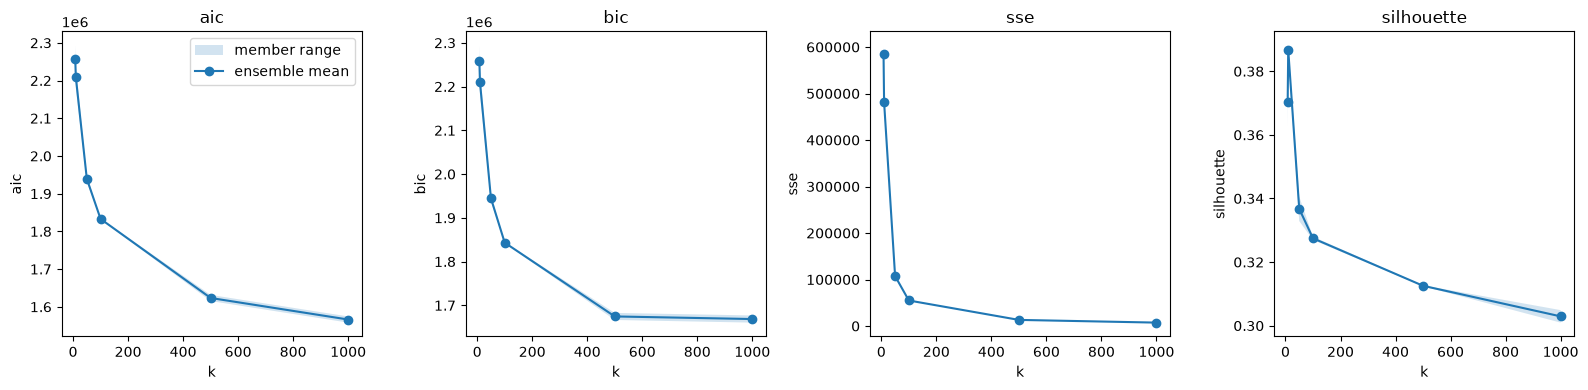

In [12]:
plot_k_metrics(scores)